In [60]:
import os
import cv2
import base64
import requests
from pathlib import Path
from ultralytics import YOLO
from IPython.display import display, Image as IPyImage

Configuration

In [61]:
# Configuration
IMAGE_DIR = "new_img"
OUTPUT_DIR = "output_dir"
MODEL_NAME = "llava-phi3"

PROMPT_TEMPLATE = """
You are a navigation safety assistant for a visually impaired user.
Based on this image of an object, say one of:
1. "[object] at [position], move [direction]"
2. "clear"
Do not explain. Only return one line.
"""

# Ensure output folder exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load YOLOv8
yolo_model = YOLO("yolov8n.pt")


LLava Query

In [62]:
def crop_and_encode(image, box):
    x1, y1, x2, y2 = map(int, box)
    cropped = image[y1:y2, x1:x2]
    _, buffer = cv2.imencode('.jpg', cropped)
    return base64.b64encode(buffer).decode("utf-8")

def query_llava_base64(encoded_img, prompt):
    payload = {
        "model": MODEL_NAME,
        "prompt": prompt,
        "images": [encoded_img],
        "stream": False
    }
    res = requests.post("http://localhost:11434/api/generate", json=payload)
    if res.ok:
        return res.json()["response"].strip().lower()
    else:
        return ""


Bounding boxes

In [63]:
def draw_danger_box(image, box, label):
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 0, 255), 2)
    cv2.putText(image, label, (x1, max(y1 - 10, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)



Run All Images

🖼️ Analyzing: 1478019960680764792_jpg.rf.110d6e91da348160db1b993d445399ee.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019960680764792_jpg.rf.110d6e91da348160db1b993d445399ee.jpg: 640x640 1 car, 86.6ms
Speed: 7.7ms preprocess, 86.6ms inference, 9.8ms postprocess per image at shape (1, 3, 640, 640)
🧠 [car] at [front and center of photo], turn right


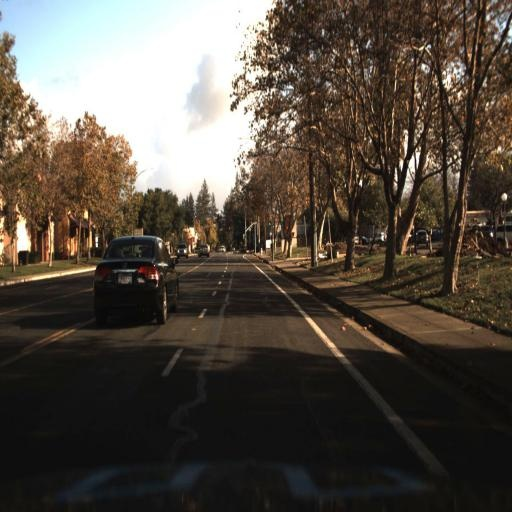

✅ No immediate hazards.
🖼️ Analyzing: 1478019958682197101_jpg.rf.XCoBnRWpmUTZFpYFGG3Y.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019958682197101_jpg.rf.XCoBnRWpmUTZFpYFGG3Y.jpg: 640x640 1 bus, 1 bench, 99.0ms
Speed: 3.4ms preprocess, 99.0ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
🧠 [object] at [position], move [direction]
🧠 1. "wide black object in background; left edge, top corner, towards the center."
2. "clear."


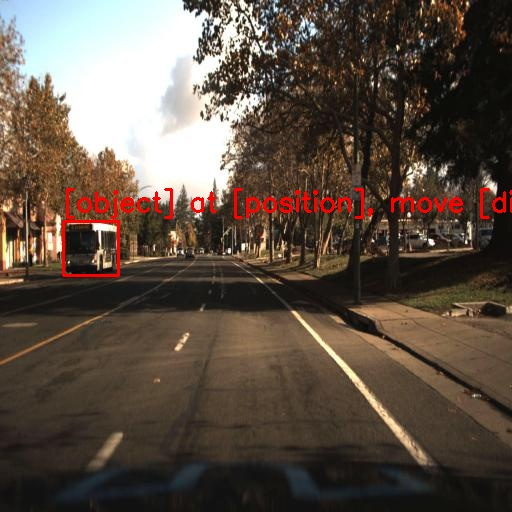

🖼️ Analyzing: 1478019954685370994_jpg.rf.Jah8pEPis5n1x6iQCtmT.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019954685370994_jpg.rf.Jah8pEPis5n1x6iQCtmT.jpg: 640x640 1 car, 96.5ms
Speed: 3.8ms preprocess, 96.5ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
🧠 [the side view mirror is black and white in color and it is attached to the car.]


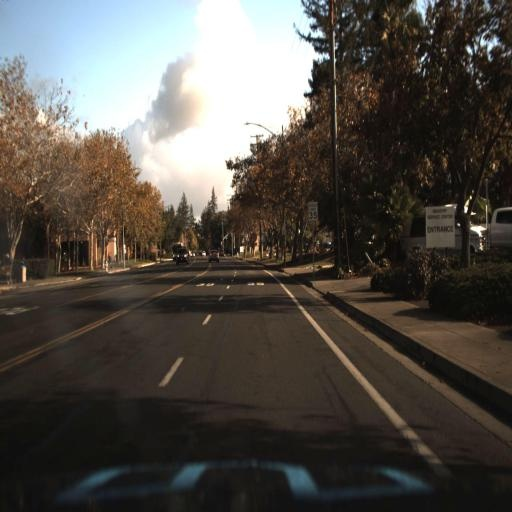

✅ No immediate hazards.
🖼️ Analyzing: 1478019955185244088_jpg.rf.gJpj2eCO1Dd7Sic9WlhE.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019955185244088_jpg.rf.gJpj2eCO1Dd7Sic9WlhE.jpg: 640x640 (no detections), 64.3ms
Speed: 1.3ms preprocess, 64.3ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)


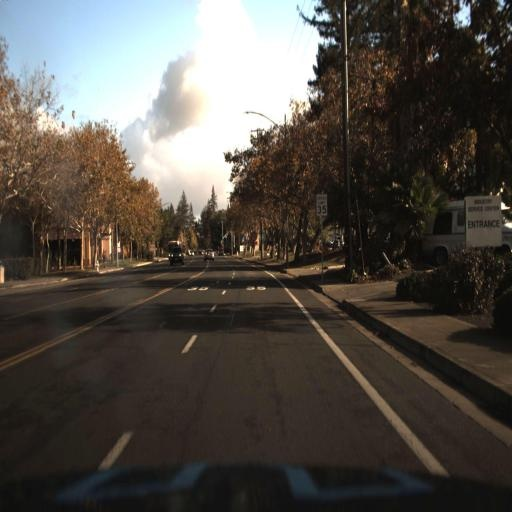

✅ No immediate hazards.
🖼️ Analyzing: 1478019958179775471_jpg.rf.cff2f9ddebcdffde85319fd59edd3421.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019958179775471_jpg.rf.cff2f9ddebcdffde85319fd59edd3421.jpg: 640x640 2 cars, 59.0ms
Speed: 1.1ms preprocess, 59.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. "black car at edge, left side, stop and scan ahead"
2. "no objects to report"
🧠 1. "blurry building in distance, moving towards it."
2. "clear street ahead, continue straight."


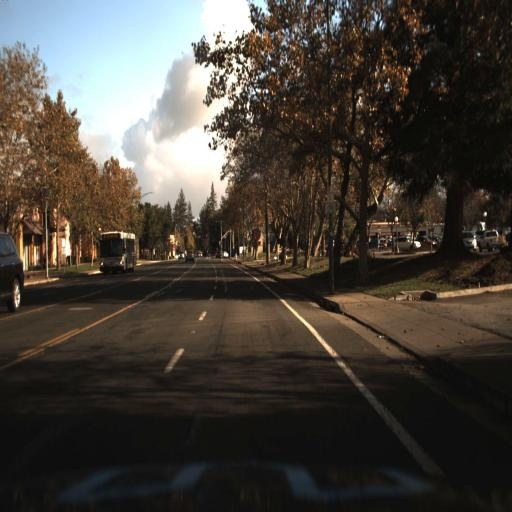

✅ No immediate hazards.
🖼️ Analyzing: 1478019952686311006_jpg.rf.JLSB3LP2Q4RuGHYKqfF6.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019952686311006_jpg.rf.JLSB3LP2Q4RuGHYKqfF6.jpg: 640x640 1 person, 112.0ms
Speed: 5.4ms preprocess, 112.0ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
🧠 [object] at [position], move [direction]


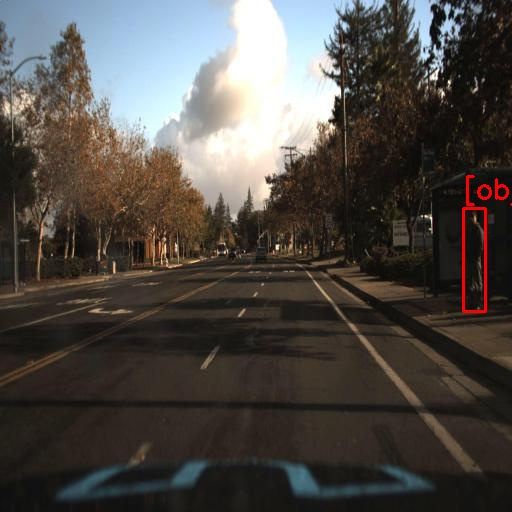

🖼️ Analyzing: 1478019957687018435_jpg.rf.fkmnRl8x2gQznYHV13Bp.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019957687018435_jpg.rf.fkmnRl8x2gQznYHV13Bp.jpg: 640x640 1 car, 1 truck, 122.3ms
Speed: 3.2ms preprocess, 122.3ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. "car is in the middle of the frame, moving forward."
🧠 1. "clear path ahead, proceed straight."


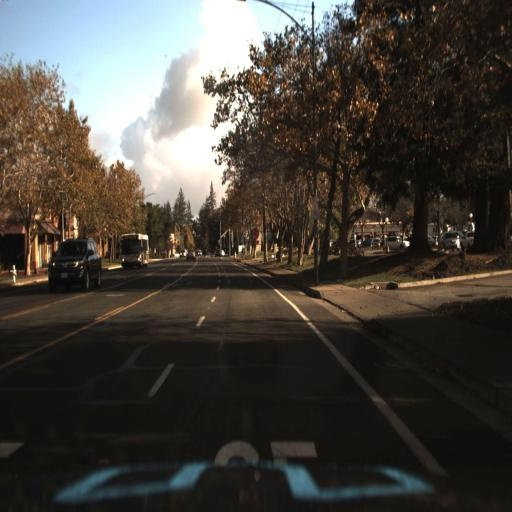

✅ No immediate hazards.
🖼️ Analyzing: 1478019961182003465_jpg.rf.1YoPELIQZqEgJpEQITU3.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019961182003465_jpg.rf.1YoPELIQZqEgJpEQITU3.jpg: 640x640 2 cars, 114.2ms
Speed: 4.6ms preprocess, 114.2ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. car parked in front of a curb and moving out with left blinker on in dark lighting conditions.
🧠 1. "blurry building in background, do not change direction."
2. "blurred object out of focus, continue straight ahead."


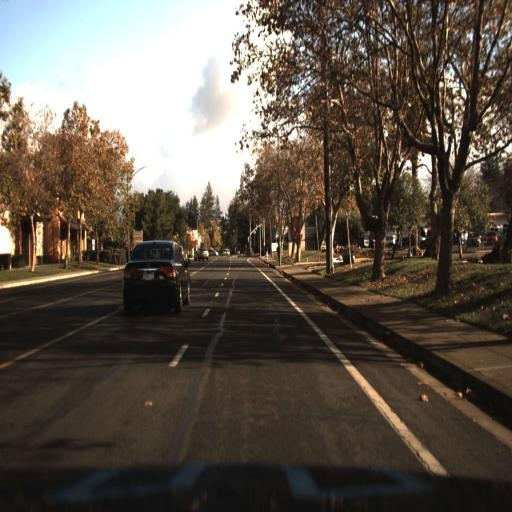

✅ No immediate hazards.
🖼️ Analyzing: 1478019961680640592_jpg.rf.QdTm8KjQ6HYfMEiUIcP6.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019961680640592_jpg.rf.QdTm8KjQ6HYfMEiUIcP6.jpg: 640x640 1 car, 133.0ms
Speed: 7.2ms preprocess, 133.0ms inference, 3.2ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. the white license plate is at the front center of the car. move towards it to get a clear view.
2. there is no object to describe.


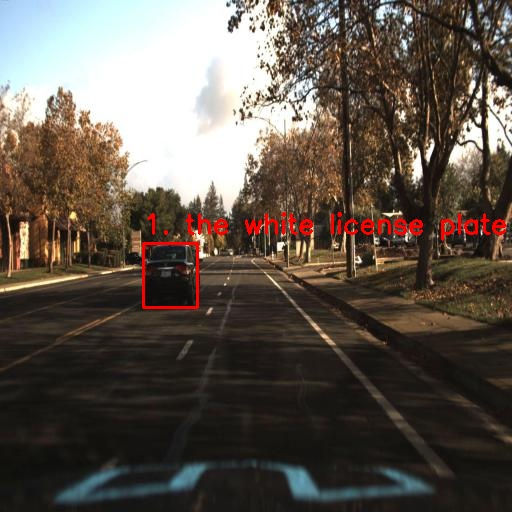

🖼️ Analyzing: 1478019953689774621_jpg.rf.2e4b7ae29c3379da1282e85cff4c1745.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019953689774621_jpg.rf.2e4b7ae29c3379da1282e85cff4c1745.jpg: 640x640 1 car, 123.2ms
Speed: 3.0ms preprocess, 123.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. "the truck is parked behind the car, so you should stop your car before proceeding."
2. "no vehicles in sight on this road."


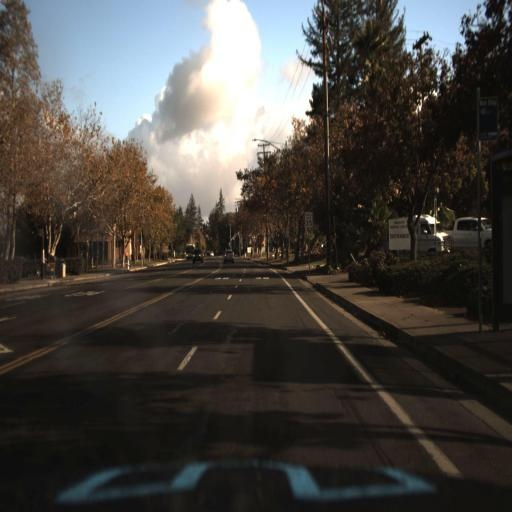

✅ No immediate hazards.
🖼️ Analyzing: 1478019956186247611_jpg.rf.9ad113e7eb74453890500935ec00590a.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019956186247611_jpg.rf.9ad113e7eb74453890500935ec00590a.jpg: 640x640 (no detections), 115.2ms
Speed: 5.8ms preprocess, 115.2ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


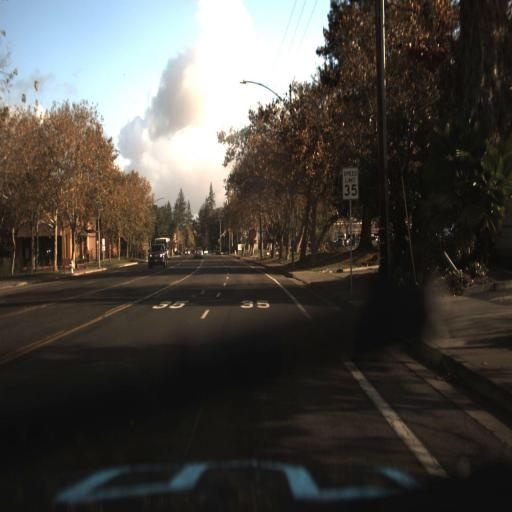

✅ No immediate hazards.
🖼️ Analyzing: 1478019953689774621_jpg.rf.UpOkvtBppZZaLfvVZ0JX.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019953689774621_jpg.rf.UpOkvtBppZZaLfvVZ0JX.jpg: 640x640 1 car, 68.0ms
Speed: 1.6ms preprocess, 68.0ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. "cars on the road, steer clear."


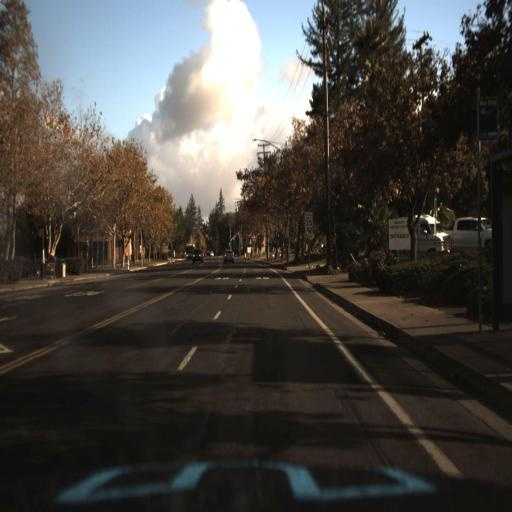

✅ No immediate hazards.
🖼️ Analyzing: 1478019953180167674_jpg.rf.azslsZnM8FLQPu3QWLTl.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019953180167674_jpg.rf.azslsZnM8FLQPu3QWLTl.jpg: 640x640 (no detections), 106.6ms
Speed: 3.1ms preprocess, 106.6ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


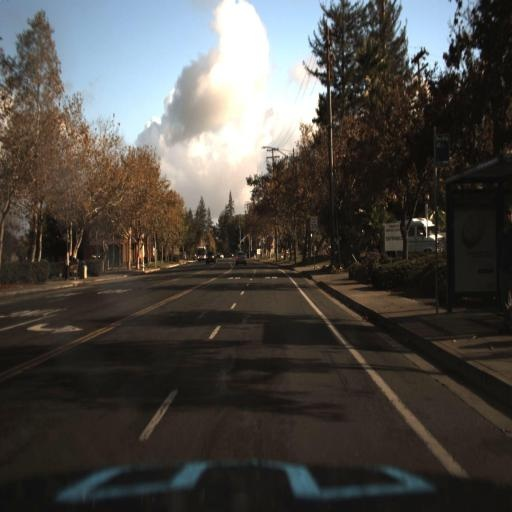

✅ No immediate hazards.
🖼️ Analyzing: 1478019960189614397_jpg.rf.579057110e268d1b10eb39053a31c988.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019960189614397_jpg.rf.579057110e268d1b10eb39053a31c988.jpg: 640x640 1 car, 75.1ms
Speed: 1.4ms preprocess, 75.1ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. car is parked by curb side, drive forward


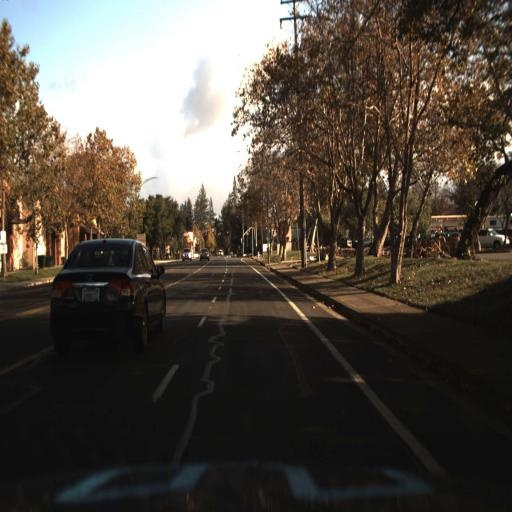

✅ No immediate hazards.
🖼️ Analyzing: 1478019959681353555_jpg.rf.e1760509335986edb309815ecd1c2401.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019959681353555_jpg.rf.e1760509335986edb309815ecd1c2401.jpg: 640x640 3 cars, 124.6ms
Speed: 4.7ms preprocess, 124.6ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. "careful in front of the car, it's moving left"

2. "nothing to worry about, everything is clear"
🧠 [object] at [position], move [direction]
🧠 [object] at [position], move [direction]


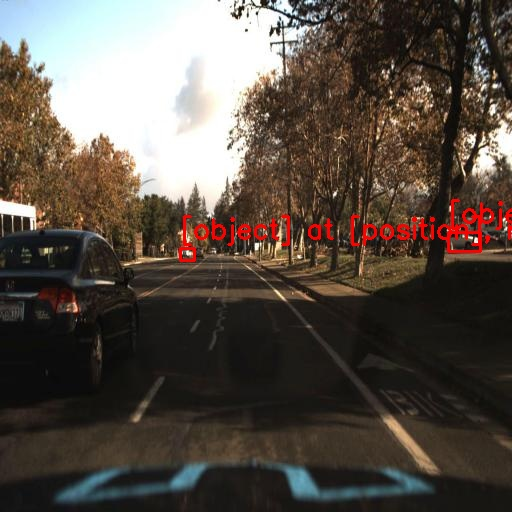

🖼️ Analyzing: 1478019961182003465_jpg.rf.6f9292b69d3508b6ab346a907dfae163.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019961182003465_jpg.rf.6f9292b69d3508b6ab346a907dfae163.jpg: 640x640 2 cars, 102.5ms
Speed: 3.9ms preprocess, 102.5ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. "parking meter is to the right, move forward."
2. "nothing obstructive in view."
🧠 1. the blurred street light is to the left, turn right.
2. blurry photo in front of me, clear ahead.


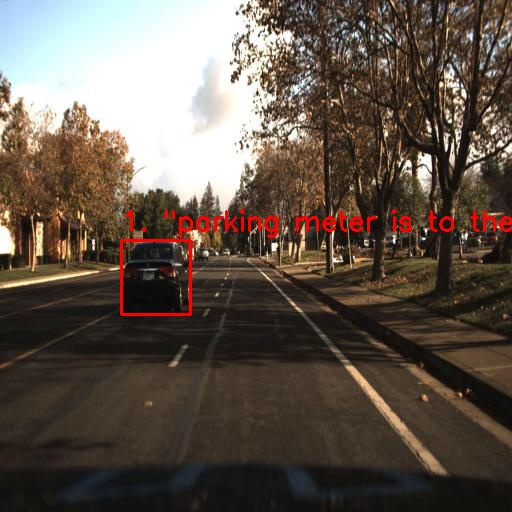

🖼️ Analyzing: 1478019954186238236_jpg.rf.f8ac6ad31e400d4918ff394f903bb95c.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019954186238236_jpg.rf.f8ac6ad31e400d4918ff394f903bb95c.jpg: 640x640 1 car, 83.7ms
Speed: 1.3ms preprocess, 83.7ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. the white car is at the right side of the frame and moving towards the left.
2. the area ahead appears to be clear.


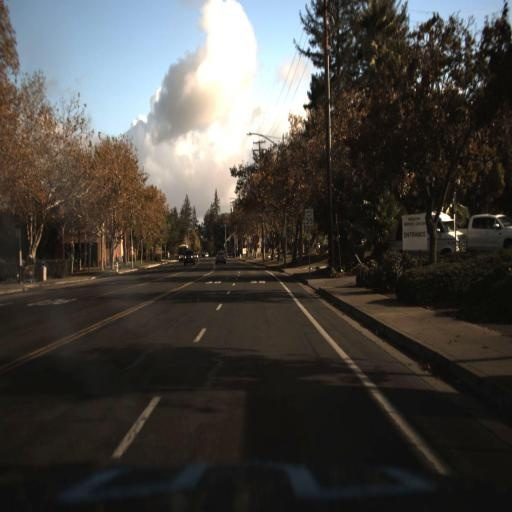

✅ No immediate hazards.
🖼️ Analyzing: 1478019954685370994_jpg.rf.049fda8ca86adf1e404b41955eb4aba8.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019954685370994_jpg.rf.049fda8ca86adf1e404b41955eb4aba8.jpg: 640x640 1 car, 106.6ms
Speed: 3.9ms preprocess, 106.6ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. "car parked in front of garage door, move forward"
2. "garage is clear to enter"


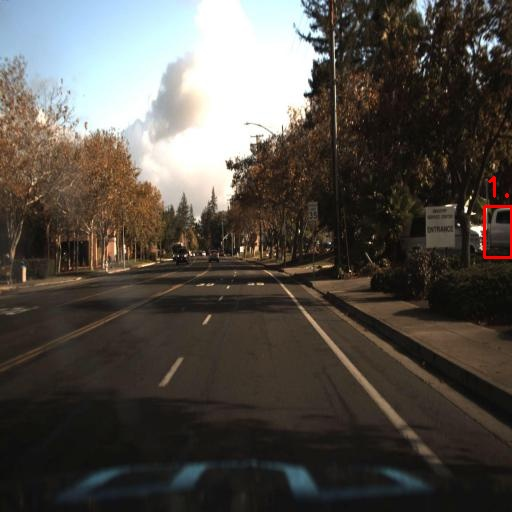

🖼️ Analyzing: 1478019958179775471_jpg.rf.YbZnPudSlDQsDo3YPZUh.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019958179775471_jpg.rf.YbZnPudSlDQsDo3YPZUh.jpg: 640x640 1 car, 85.5ms
Speed: 4.3ms preprocess, 85.5ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. the tire is black and visible in the lower left corner of the frame, turn to the right
2. there are no obstructions in the view


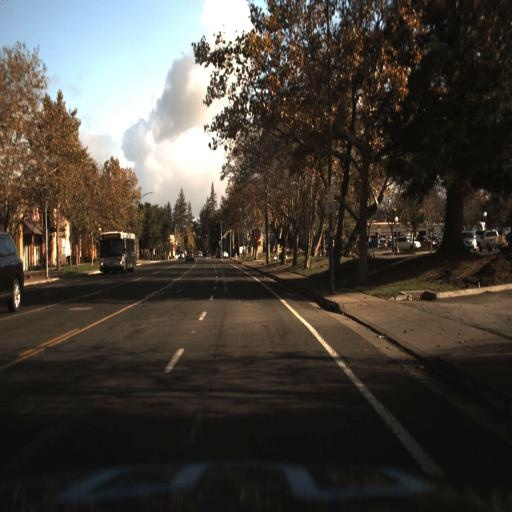

✅ No immediate hazards.
🖼️ Analyzing: 1478019953180167674_jpg.rf.8a816c9d7e9b423a63ed6ecd4a663e47.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019953180167674_jpg.rf.8a816c9d7e9b423a63ed6ecd4a663e47.jpg: 640x640 (no detections), 104.9ms
Speed: 3.7ms preprocess, 104.9ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


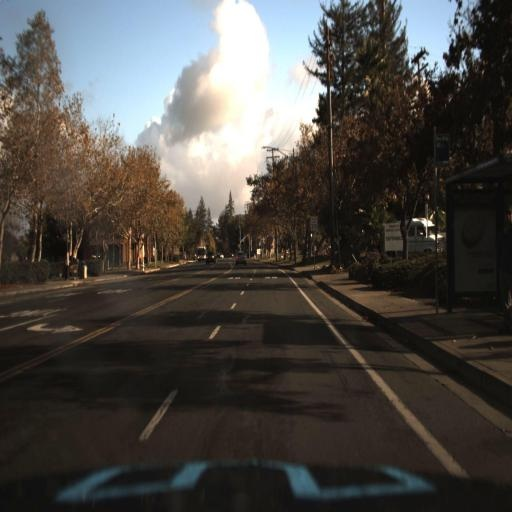

✅ No immediate hazards.
🖼️ Analyzing: 1478019961680640592_jpg.rf.4a7d9525ca078f67bd1f6eb6cf609899.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019961680640592_jpg.rf.4a7d9525ca078f67bd1f6eb6cf609899.jpg: 640x640 1 car, 79.3ms
Speed: 1.5ms preprocess, 79.3ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. "car parked in front of the building, move forward."
2. "the area is clear."


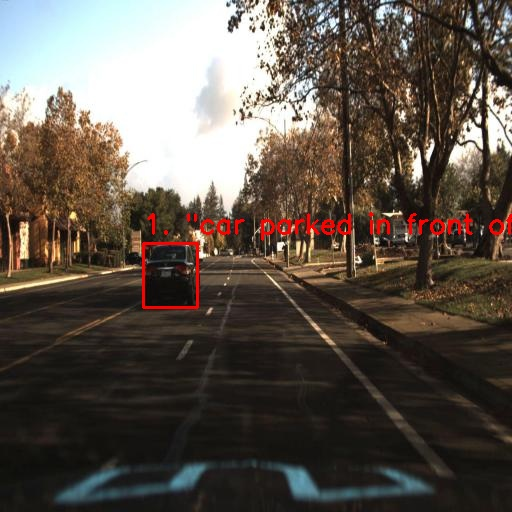

🖼️ Analyzing: 1478019960189614397_jpg.rf.Z5AUNjIXYDkZnux8iRdA.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019960189614397_jpg.rf.Z5AUNjIXYDkZnux8iRdA.jpg: 640x640 1 car, 125.2ms
Speed: 2.6ms preprocess, 125.2ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. a black car with a license plate that has the word world in white on it is parked next to a yellow pole. the car is on the right side of the image and facing towards the left. move away from this car.
2. clear


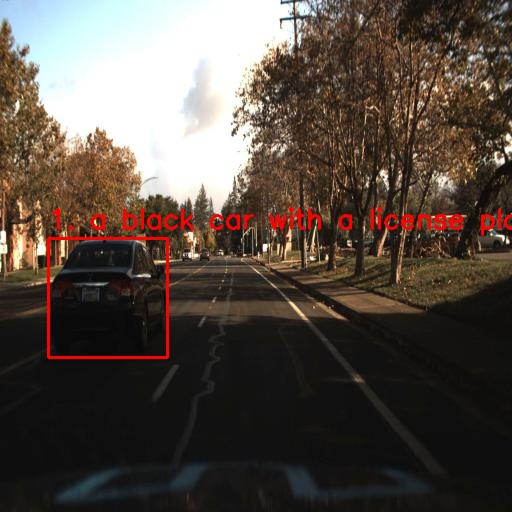

🖼️ Analyzing: 1478019959681353555_jpg.rf.PeekubBi5BYh0Fx5ClIV.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019959681353555_jpg.rf.PeekubBi5BYh0Fx5ClIV.jpg: 640x640 3 cars, 99.4ms
Speed: 3.6ms preprocess, 99.4ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. "car parked in a spot, stay right for safety"
2. "clear to go!"
🧠 1. there is an obstacle in the way and you need to turn left to avoid it. move slowly.
2. the path ahead is clear.
🧠 1. "blurry building in front, turn left"


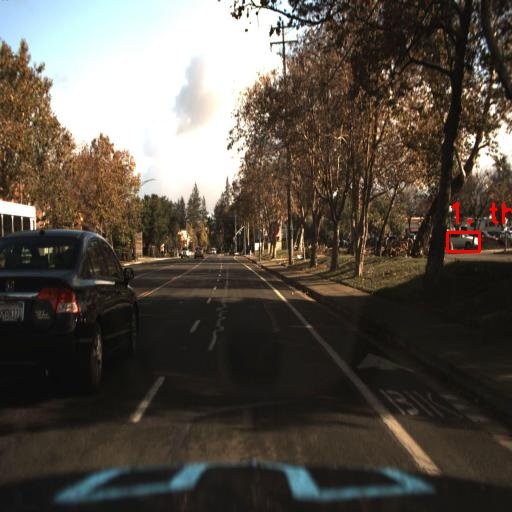

🖼️ Analyzing: 1478019952686311006_jpg.rf.54e2d12dbabc46be3c78995b6eaf3fee.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019952686311006_jpg.rf.54e2d12dbabc46be3c78995b6eaf3fee.jpg: 640x640 1 person, 1 bird, 111.8ms
Speed: 1.8ms preprocess, 111.8ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. "the person is facing away from the wall and seems to be moving towards the top right corner of the image."
2. "there is no object in the image, it appears to be a clear path."
🧠 1. "the blurry brown and white lines are going upwards from the bottom left to the top right, so you should continue moving in that direction."
2. "there is no object or obstacle visible in this image."


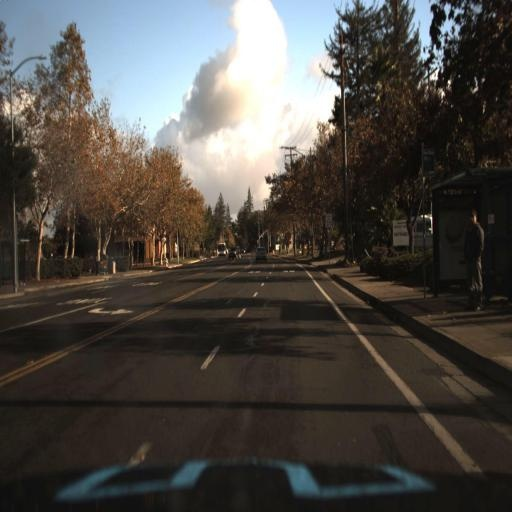

✅ No immediate hazards.
🖼️ Analyzing: 1478019959187829768_jpg.rf.05756574b448018fc4167576c84e1fe4.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019959187829768_jpg.rf.05756574b448018fc4167576c84e1fe4.jpg: 640x640 1 car, 1 bus, 157.3ms
Speed: 5.1ms preprocess, 157.3ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. "car at 60 degrees to the right, move forward"
2. "clear"
🧠 1. "the bus is parked in front of the building."
2. "this image does not contain any objects to provide directions for."


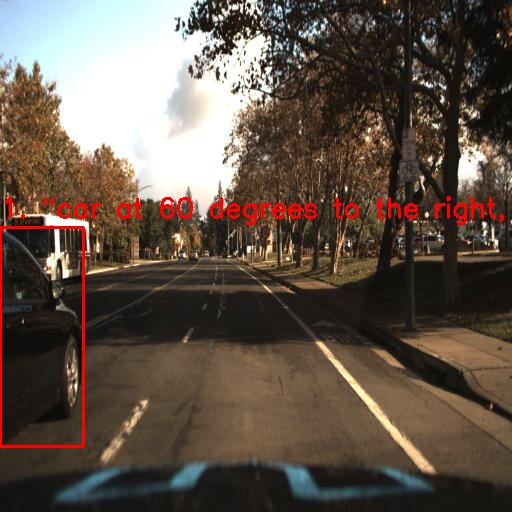

🖼️ Analyzing: 1478019957180061202_jpg.rf.YHpll4d5Wk2IKGKflOe3.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019957180061202_jpg.rf.YHpll4d5Wk2IKGKflOe3.jpg: 640x640 2 cars, 1 bus, 1 truck, 116.0ms
Speed: 9.7ms preprocess, 116.0ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. "the blurry car is at the center of the photo, moving forward."
🧠 1. object is in foreground; direction is up and left.
🧠 1. "the black train at the platform is stationary."
2. "there are no objects in the image."
🧠 1. "move right at the top left, avoiding the blurry section in the center."


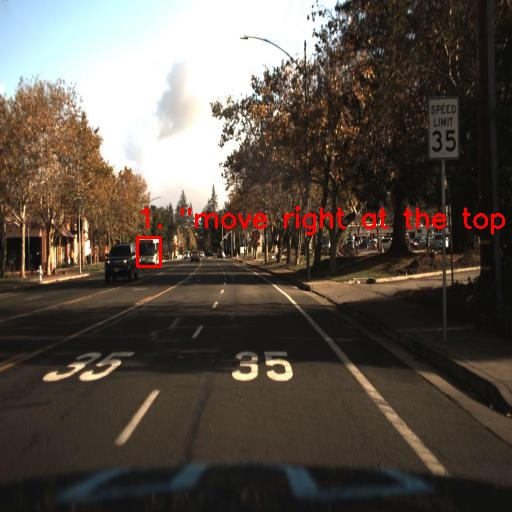

🖼️ Analyzing: 1478019956186247611_jpg.rf.GnF8WwC0ZJpj6eNo46lF.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019956186247611_jpg.rf.GnF8WwC0ZJpj6eNo46lF.jpg: 640x640 (no detections), 102.4ms
Speed: 2.4ms preprocess, 102.4ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


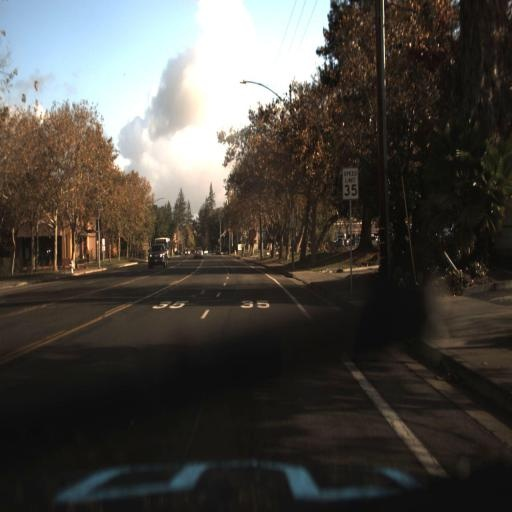

✅ No immediate hazards.
🖼️ Analyzing: 1478019962181150666_jpg.rf.230d158a17ea339ca53495e948e85bc7.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019962181150666_jpg.rf.230d158a17ea339ca53495e948e85bc7.jpg: 640x640 4 cars, 61.5ms
Speed: 1.2ms preprocess, 61.5ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. black car at 6 o'clock, turn left and stop.
2. clear
🧠 1. the large black vehicle is in the right lane, it's blurred but i can still see its red headlights. move to the left and get out of its way.
2. no obstacles detected.
🧠 [object] at [position], move [direction]
🧠 1. object is red letter p at center, move right
2. clear


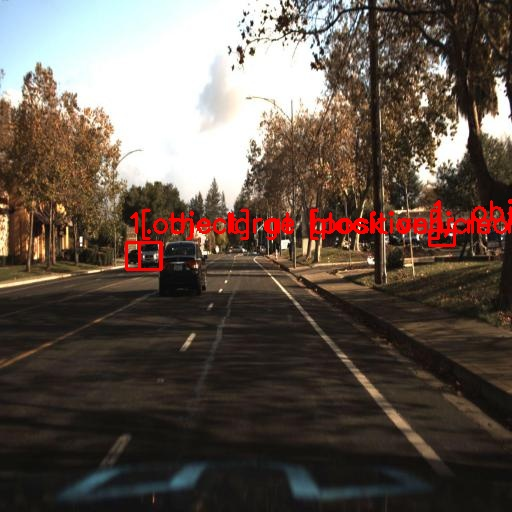

🖼️ Analyzing: 1478019955679801306_jpg.rf.QnW1eAO23mmDm9ap1gm7.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019955679801306_jpg.rf.QnW1eAO23mmDm9ap1gm7.jpg: 640x640 1 car, 1 bus, 91.1ms
Speed: 2.5ms preprocess, 91.1ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. the white van is parked in front of the tree. move forward until you reach the sidewalk. turn right and continue walking straight ahead.
2. clear
🧠 * clear road ahead and light directional street sign (white arrow pointing right) are visible. move straight or turn right to continue on the correct path.
* no objects detected at this position, clear to proceed.


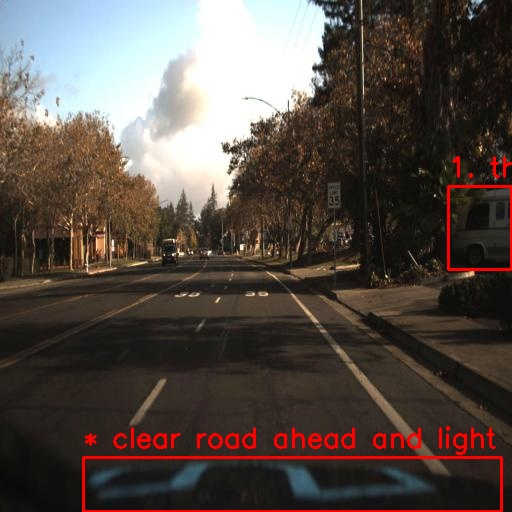

🖼️ Analyzing: 1478019955679801306_jpg.rf.e0c1afab5b4a00d9812e56907cd1b9bf.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019955679801306_jpg.rf.e0c1afab5b4a00d9812e56907cd1b9bf.jpg: 640x640 1 bus, 96.8ms
Speed: 1.9ms preprocess, 96.8ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. "the front tire of the truck is visible in the photo. move towards it."


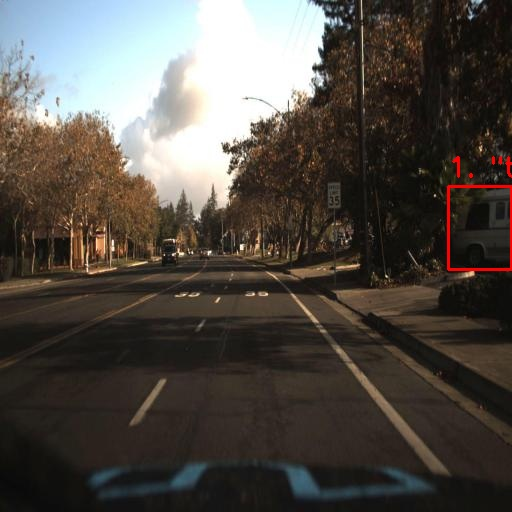

🖼️ Analyzing: 1478019957180061202_jpg.rf.cdefcc1c676aa9a6abcacbe79fff26f6.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019957180061202_jpg.rf.cdefcc1c676aa9a6abcacbe79fff26f6.jpg: 640x640 2 cars, 1 bus, 1 truck, 112.0ms
Speed: 5.1ms preprocess, 112.0ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. "car at 50% screen height, move down"
🧠 1. "a car parked to the left of a building with two lights, turn right."
🧠 1. "the door is closed and in the middle of the hallway." (this means that there are two doors, and this one is closed)
2. "[object] in [position], do nothing" (this means that there is no obstacle or object to avoid)
🧠 1. red pole in left foreground at top edge, move right
2. clear


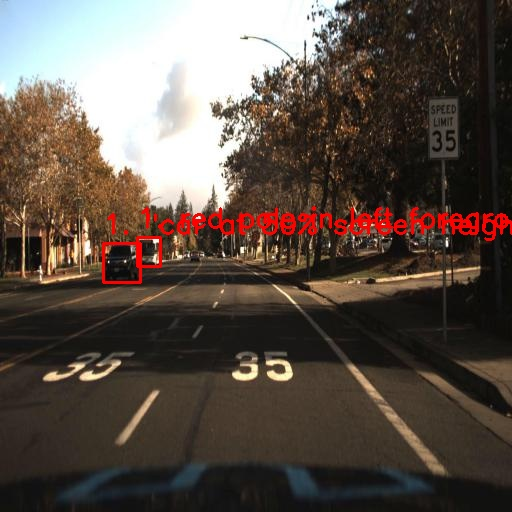

🖼️ Analyzing: 1478019954186238236_jpg.rf.cbpP963e2sN7rHIZMJtD.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019954186238236_jpg.rf.cbpP963e2sN7rHIZMJtD.jpg: 640x640 1 car, 109.0ms
Speed: 2.3ms preprocess, 109.0ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. "[car is in the left side of the road, go straight ahead]"
2. "[clearance on both sides are clear]"


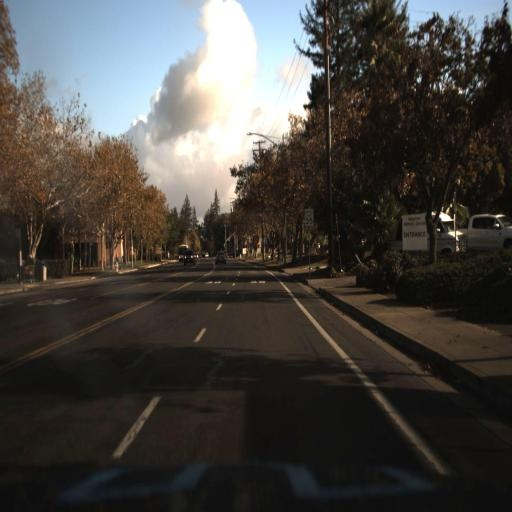

✅ No immediate hazards.
🖼️ Analyzing: 1478019958682197101_jpg.rf.86b125654879c636e92f4bfb807fb296.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019958682197101_jpg.rf.86b125654879c636e92f4bfb807fb296.jpg: 640x640 1 bus, 137.7ms
Speed: 3.8ms preprocess, 137.7ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. object is black at 6 o'clock position, turn right and walk forward two steps to clear it.
2. object is black at 7 o'clock position, move forward four steps to clear it.


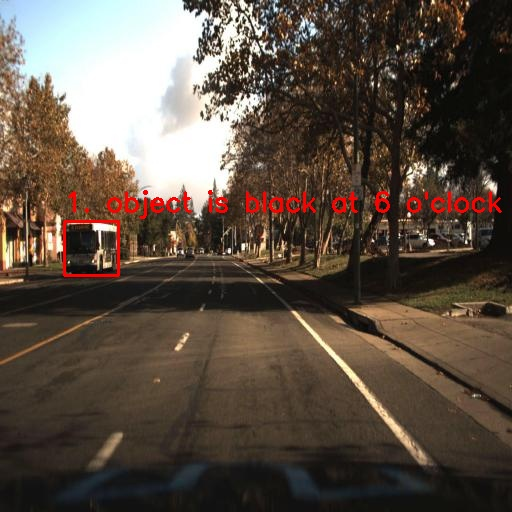

🖼️ Analyzing: 1478019960680764792_jpg.rf.JzgjCNvlnf4KVqsEyFn6.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019960680764792_jpg.rf.JzgjCNvlnf4KVqsEyFn6.jpg: 640x640 1 car, 105.3ms
Speed: 3.5ms preprocess, 105.3ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. car parked at sidewalk, do nothing
2. car behind the car in front, clear


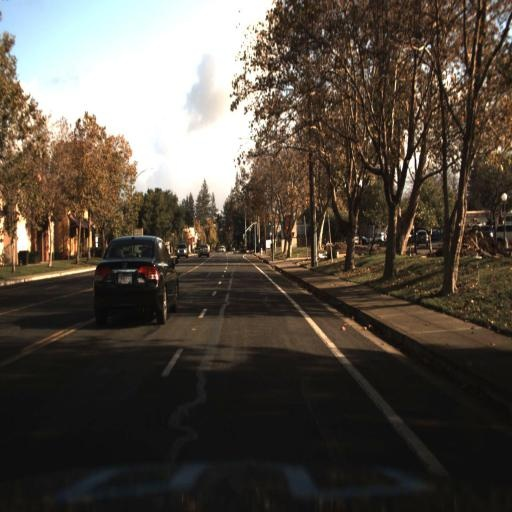

✅ No immediate hazards.
🖼️ Analyzing: 1478019959187829768_jpg.rf.UdTiXYVJQPlo7cvSdGVU.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019959187829768_jpg.rf.UdTiXYVJQPlo7cvSdGVU.jpg: 640x640 1 car, 1 bus, 129.5ms
Speed: 4.6ms preprocess, 129.5ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. a car parked in a parking space near the curb and close to two other cars and buses. move forward.
🧠 1. "a white bus in the right lane moving away from you."
2. "nothing visible in your path, proceed carefully."


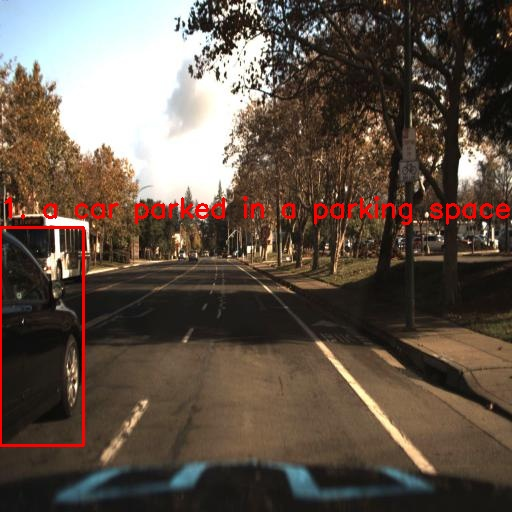

🖼️ Analyzing: 1478019956680248165_jpg.rf.wBTBnKX8QeE4p8Zywg3O.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019956680248165_jpg.rf.wBTBnKX8QeE4p8Zywg3O.jpg: 640x640 2 cars, 109.6ms
Speed: 5.2ms preprocess, 109.6ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. "the handle is located at the top center position and moves downward."
2. "there are no objects to navigate around."
🧠 1. a wall at the end of the hallway, turn left at the end of the hallway.


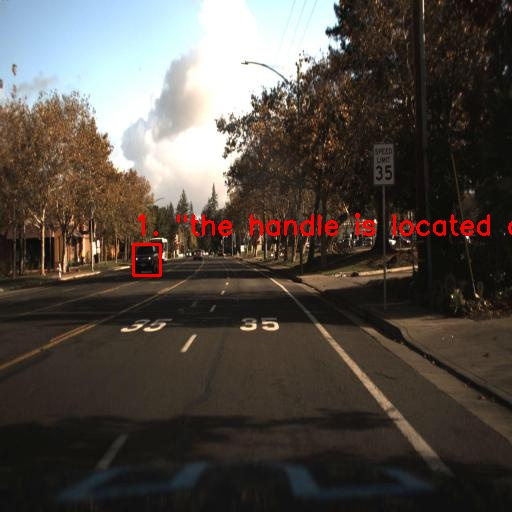

🖼️ Analyzing: 1478019956680248165_jpg.rf.ad9d5ee7e46edd991b6c6ff8d3f10644.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019956680248165_jpg.rf.ad9d5ee7e46edd991b6c6ff8d3f10644.jpg: 640x640 1 car, 114.8ms
Speed: 2.4ms preprocess, 114.8ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. "slide door in front to open car, move forward"


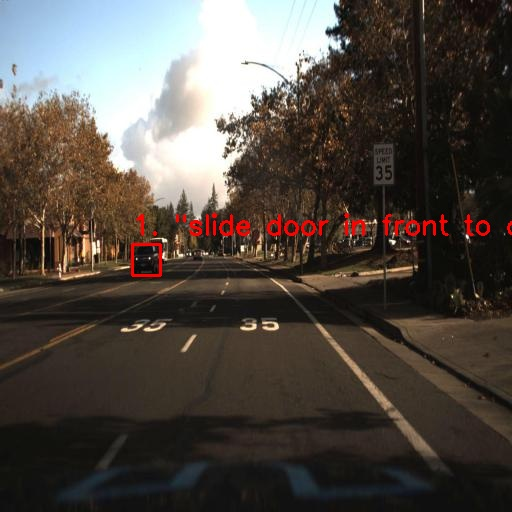

🖼️ Analyzing: 1478019957687018435_jpg.rf.f4d1d5ec89c63e083d0930dd819271d4.jpg

image 1/1 /Users/rianachatterjee/Downloads/in-lab/YOLO_VLM_switch_off/new_img/1478019957687018435_jpg.rf.f4d1d5ec89c63e083d0930dd819271d4.jpg: 640x640 1 car, 1 truck, 113.9ms
Speed: 3.7ms preprocess, 113.9ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)
🧠 1. "vehicle in the foreground. awaiting further instructions."
2. "object obscured by darkness, no action required."
🧠 1. "black wall tile at [0.23, 0.54, 0.76, 0.98] moves upwards towards the left side of image"
2. "wall tiles blurred in background"


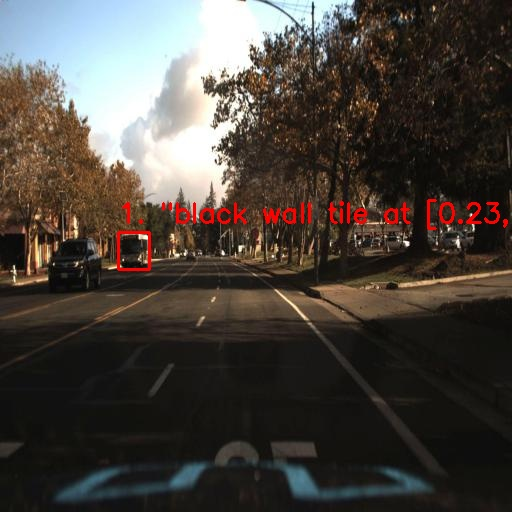

In [64]:
# Run detection + interpretation
for img_path in Path(IMAGE_DIR).glob("*.*"):
    print(f"🖼️ Analyzing: {img_path.name}")
    image = cv2.imread(str(img_path))
    result = yolo_model(str(img_path))[0]

    threat_detected = False

    for box in result.boxes.xyxy.cpu().numpy():
        encoded_crop = crop_and_encode(image, box)
        response = query_llava_base64(encoded_crop, PROMPT_TEMPLATE)
        print("🧠", response)

        if "move" in response:
            threat_detected = True
            draw_danger_box(image, box, response)

    # Save and display
    out_path = os.path.join(OUTPUT_DIR, img_path.name)
    cv2.imwrite(out_path, image)
    display(IPyImage(filename=out_path))

    if not threat_detected:
        print("✅ No immediate hazards.")